# 3단계: Helmholtz PINN — BM 근방 파동방정식 AI 학습

## 이 노트북에서 하는 일

```
AR코팅(TMM) → Cover Glass(ASM) → [BM 근방 30μm] → OPD 센서
                                        ↑
                                  지금 여기를 PINN으로 풀기
```

**Helmholtz 방정식**이라는 파동 물리 법칙을 신경망에 가르쳐서,  
BM(Black Matrix) 콜리메이터 근방의 복소 광학 필드를 계산합니다.

---
**PINN이 뭔가요?**  
일반 AI는 데이터만 보고 학습합니다.  
PINN은 데이터 + 물리 법칙(미분방정식)을 동시에 만족하도록 학습합니다.  
→ 데이터가 적어도 물리적으로 올바른 결과를 냅니다.

**손실 함수 5항:**
$$L = \lambda_1 L_{pde} + \lambda_2 L_{bm} + \lambda_3 L_{fresnel} + \lambda_4 L_{data} + \lambda_5 L_{phase}$$
| 항 | 역할 |
|---|---|
| $L_{pde}$ | Helmholtz 방정식 만족 |
| $L_{bm}$ | BM 불투명 영역 U=0 강제 |
| $L_{fresnel}$ | 계면 연속 조건 |
| $L_{data}$ | 실측 강도 데이터 피팅 |
| $L_{phase}$ ★ | TMM 위상 경계조건 강제 (핵심 차별점) |

## 0. 도구 불러오기

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib
import json, time

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# GPU 사용 가능 여부 확인 (없으면 CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch 버전: {torch.__version__}')
print(f'사용 장치   : {device}')
print(f'  (GPU가 있으면 훨씬 빠릅니다. 지금은 CPU로 간소화 학습)')

# 재현성을 위한 시드 고정
torch.manual_seed(42)
np.random.seed(42)
print('\n✓ 초기화 완료')

## 1. 물리 도메인 설정

BM 근방 30μm 영역의 굴절률 분포를 정의합니다.

```
z=0  (상단): ASM 결과 U_CG_out 입력
 ↓
 BM 구조 (불투명 TiO₂ 벽, n=1.6+2i)
 SiO₂ 아퍼처 (투명, n=1.46)
 ↓
z=30μm (하단): PSF = |U|²  → OPD 센서
```

In [ ]:
# ── 물리 파라미터 (단위: μm 통일) ──
wavelength_um = 0.85
k0_um         = 2*np.pi / wavelength_um   # ≈ 7.39 μm⁻¹

# BM 도메인 (μm)
x_min, x_max = -400.0, 400.0
z_min, z_max =    0.0,  30.0

# BM 설계 파라미터 (μm)
w1       = 30.0    # BM1 아퍼처 폭
w2       = 40.0    # BM2 아퍼처 폭
t_BM     = 10.0    # BM 두께
d_int    = 20.0    # BM 간격
delta_BM = -9.0    # ★ 선형 추정 최적값: skewness < 0.10 목표

# 굴절률
n_BM   = 1.6 + 2j
n_SiO2 = 1.46
sigma0 = 100.0   # 광원 가우시안 폭 (μm)

print(f'파라미터 (μm 단위):')
print(f'  파장     : {wavelength_um} μm  ({wavelength_um*1000:.0f} nm)')
print(f'  k₀       : {k0_um:.3f} μm⁻¹')
print(f'  도메인 x : {x_min} ~ {x_max} μm')
print(f'  도메인 z : {z_min} ~ {z_max} μm')
print(f'  BM 아퍼처: w1={w1}μm, w2={w2}μm')
print(f'  ★ delta_BM: {delta_BM} μm  (BM1 오프셋, skewness 보정)')


def get_n2_mask(x_pts, z_pts, w1=w1, w2=w2, t_BM=t_BM, d_int=d_int, delta=delta_BM):
    """BM 영역 여부 반환 (True = BM 불투명)"""
    bm2 = (z_pts < t_BM) & ((x_pts < -w2/2) | (x_pts > w2/2))
    z1, z2 = t_BM + d_int, 2*t_BM + d_int
    bm1 = (z_pts > z1) & (z_pts < z2) & \
          ((x_pts < (-w1/2 + delta)) | (x_pts > (w1/2 + delta)))
    return bm2 | bm1


# BM 구조 시각화
Nx_vis, Nz_vis = 400, 150
xv = np.linspace(x_min, x_max, Nx_vis)
zv = np.linspace(z_min, z_max, Nz_vis)
XV, ZV = np.meshgrid(xv, zv)
xv_t = torch.tensor(XV.ravel(), dtype=torch.float32)
zv_t = torch.tensor(ZV.ravel(), dtype=torch.float32)
bm_map = get_n2_mask(xv_t, zv_t).numpy().reshape(Nz_vis, Nx_vis).astype(float)

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(bm_map, extent=[x_min, x_max, z_max, z_min],
               aspect='auto', cmap='Reds')
plt.colorbar(im, ax=ax, label='BM 불투명 영역')
ax.set_xlabel('x (μm)'); ax.set_ylabel('z (μm)')
ax.set_title(f'BM 구조 단면도  (delta_BM={delta_BM}μm 적용)', fontweight='bold')
ax.axhline(t_BM,         color='blue',  ls='--', lw=1, label=f'BM2 하단 z={t_BM}μm')
ax.axhline(t_BM + d_int, color='green', ls='--', lw=1, label=f'BM1 상단 z={t_BM+d_int}μm')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('BM_구조_최적.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ BM 구조 시각화 완료')


## 2. SIREN 신경망 구조 정의

**SIREN (Sinusoidal Representation Network)**  
활성화 함수로 sin을 사용해서 고주파 광학 필드를 잘 학습합니다.

- 입력: (x, z) 좌표 + BM 설계 파라미터 8개
- 출력: (U_real, U_imag) — 복소 필드의 실부·허부
- 구조: 4층 × 128 유닛 (간소화 버전)

In [ ]:
class SIRENLayer(nn.Module):
    """SIREN 단일 층: sin(ω₀ · (Wx + b))"""
    def __init__(self, in_dim, out_dim, omega0=30.0, is_first=False):
        super().__init__()
        self.omega0   = omega0
        self.is_first = is_first
        self.linear   = nn.Linear(in_dim, out_dim)
        self._init_weights()

    def _init_weights(self):
        with torch.no_grad():
            if self.is_first:
                # 첫 번째 층: 균등 분포 초기화
                nn.init.uniform_(self.linear.weight, -1/self.linear.in_features,
                                                      1/self.linear.in_features)
            else:
                # 나머지 층: SIREN 논문 권장 초기화
                bound = np.sqrt(6 / self.linear.in_features) / self.omega0
                nn.init.uniform_(self.linear.weight, -bound, bound)

    def forward(self, x):
        return torch.sin(self.omega0 * self.linear(x))


class HelmholtzPINN(nn.Module):
    """
    Helmholtz PINN 신경망
    입력: (x_norm, z_norm)  — 정규화된 좌표
    출력: (U_real, U_imag)  — 복소 필드
    """
    def __init__(self, hidden_dim=128, n_layers=4, omega0=30.0):
        super().__init__()
        layers = [SIRENLayer(2, hidden_dim, omega0=omega0, is_first=True)]
        for _ in range(n_layers - 1):
            layers.append(SIRENLayer(hidden_dim, hidden_dim, omega0=omega0))
        self.net    = nn.Sequential(*layers)
        self.output = nn.Linear(hidden_dim, 2)   # → (U_real, U_imag)

    def forward(self, x_norm, z_norm):
        coords = torch.stack([x_norm, z_norm], dim=-1)   # (N, 2)
        h      = self.net(coords)
        out    = self.output(h)                           # (N, 2)
        return out[:, 0], out[:, 1]                       # U_real, U_imag

    def get_U(self, x_norm, z_norm):
        """복소 필드 U = U_real + i·U_imag 반환"""
        Ur, Ui = self.forward(x_norm, z_norm)
        return torch.complex(Ur, Ui)


# 모델 생성
model = HelmholtzPINN(hidden_dim=128, n_layers=4, omega0=30.0).to(device)

# 파라미터 수 확인
n_params = sum(p.numel() for p in model.parameters())
print(f'✓ PINN 모델 생성 완료')
print(f'  구조: SIREN 4층 × 128 유닛')
print(f'  총 파라미터 수: {n_params:,}개')
print(f'  장치: {device}')

## 3. 콜로케이션 포인트 생성

PINN 학습에 필요한 **계산 포인트**들을 준비합니다.

| 종류 | 수량 | 역할 |
|------|------|------|
| PDE interior | 2,000개 | Helmholtz 방정식 잔차 계산 |
| BM Dirichlet | 400개 | BM 불투명 영역 U=0 강제 |
| 경계 (상단) | 300개 | ASM 결과를 경계조건으로 입력 |

In [ ]:
# ── 좌표 정규화 (μm → [-1, 1]) ──
def normalize(x_pts, z_pts):
    xn = (x_pts - x_min) / (x_max - x_min) * 2 - 1
    zn = (z_pts - z_min) / (z_max - z_min) * 2 - 1
    return xn, zn

Jx = (x_max - x_min) / 2.0   # μm
Jz = (z_max - z_min) / 2.0   # μm

# ── 1) PDE 내부 포인트 ──
N_pde = 2000
x_pde = torch.FloatTensor(N_pde).uniform_(x_min, x_max)
z_pde = torch.FloatTensor(N_pde).uniform_(z_min, z_max)

# ── 2) BM 불투명 포인트 ──
N_bm  = 400
x_bm2 = torch.cat([torch.FloatTensor(N_bm//2).uniform_(x_min, -w2/2),
                    torch.FloatTensor(N_bm//2).uniform_(w2/2,  x_max)])
z_bm2 = torch.FloatTensor(N_bm).uniform_(0, t_BM)
x_bm1 = torch.cat([torch.FloatTensor(N_bm//2).uniform_(x_min, -w1/2),
                    torch.FloatTensor(N_bm//2).uniform_(w1/2,  x_max)])
z_bm1 = torch.FloatTensor(N_bm).uniform_(t_BM + d_int, 2*t_BM + d_int)
x_bm  = torch.cat([x_bm2, x_bm1])
z_bm  = torch.cat([z_bm2, z_bm1])

# ── 3) 상단 경계 (z=0) — 최적화된 TMM 위상 사용 ──
N_bc = 300
x_bc = torch.linspace(x_min, x_max, N_bc)
z_bc = torch.zeros(N_bc)

# ★ 최적 설계 파라미터 (optimal_design.json 결과 적용)
import json as _json
with open('optimal_design.json', 'r') as _f:
    _opt = _json.load(_f)

theta_inc    = 30.0          # 최적화 조건 (θ=30°)
n_SiO2_val   = 1.46
n_TiO2_val   = 2.35
wavelength_m = 850e-9

# 최적 두께 (nm → m)
_t_nm = _opt['best_design']['thickness_nm']
gorilla_DX_opt = [
    (n_SiO2_val, _t_nm[0] * 1e-9),
    (n_TiO2_val, _t_nm[1] * 1e-9),
    (n_SiO2_val, _t_nm[2] * 1e-9),
    (n_TiO2_val, _t_nm[3] * 1e-9),
]

print(f'★ 최적 코팅 두께 적용 (θ={theta_inc}°):')
for i, (n_l, d_l) in enumerate(gorilla_DX_opt):
    mat = 'SiO2' if n_l == n_SiO2_val else 'TiO2'
    print(f'  Layer {i+1} ({mat}): {d_l*1e9:.2f} nm')

def tmm_compute(layers, n_in, n_out, theta_deg, wl):
    kx  = n_in * np.sin(np.radians(theta_deg))
    k0_ = 2 * np.pi / wl
    M   = np.eye(2, dtype=complex)
    for n_j, d_j in layers:
        cos_j = np.sqrt(complex(n_j**2 - kx**2))
        dj    = k0_ * cos_j * d_j
        Mj    = np.array([[np.cos(dj), -1j*np.sin(dj)/cos_j],
                          [-1j*cos_j*np.sin(dj), np.cos(dj)]], dtype=complex)
        M = M @ Mj
    p_in  = np.sqrt(complex(n_in**2  - kx**2))
    p_out = np.sqrt(complex(n_out**2 - kx**2))
    t = 2*p_in / ((M[0,0] + M[0,1]*p_out)*p_in + (M[1,0] + M[1,1]*p_out))
    return float(abs(t)**2 * p_out.real / p_in.real), t

T_th, t_th = tmm_compute(gorilla_DX_opt, 1.0, 1.52, theta_inc, wavelength_m)
_,    t_0  = tmm_compute(gorilla_DX_opt, 1.0, 1.52, 0.0,       wavelength_m)
dphi_rad   = float(np.angle(t_th) - np.angle(t_0))

# 경계 조건 생성
kx_tilt_um = float(k0_um * np.sin(np.radians(theta_inc)))
x_np       = x_bc.numpy()
G_bc       = np.exp(-x_np**2 / (2*sigma0**2))
U_bc_np    = np.sqrt(T_th) * G_bc * np.exp(1j*(kx_tilt_um*x_np + dphi_rad))
U_bc_real  = torch.tensor(U_bc_np.real, dtype=torch.float32)
U_bc_imag  = torch.tensor(U_bc_np.imag, dtype=torch.float32)

# GPU 전송
x_pde=x_pde.to(device); z_pde=z_pde.to(device)
x_bm=x_bm.to(device);   z_bm=z_bm.to(device)
x_bc=x_bc.to(device);   z_bc=z_bc.to(device)
U_bc_real=U_bc_real.to(device); U_bc_imag=U_bc_imag.to(device)

print(f'\n✓ 콜로케이션 포인트 생성 완료')
print(f'  TMM 투과율: {T_th*100:.2f}%')
print(f'  TMM Δφ    : {np.degrees(dphi_rad):.2f}°  (θ={theta_inc}°)')
print(f'  kx_tilt   : {kx_tilt_um:.3f} μm⁻¹')


## 4. 손실 함수 정의

In [ ]:
def compute_losses(model, x_pde_in, z_pde_in, x_bm, z_bm,
                   x_bc, z_bc, U_bc_real, U_bc_imag,
                   lam1=1.0, lam2=10.0, lam4=5.0, lam5=3.0):
    """
    5항 손실 계산 (μm 단위, L-BFGS 안전 버전)
    핵심: detach().clone().requires_grad_(True) 로 매번 새 그래프 생성
    """
    # ── L_pde: Helmholtz  ∇²U + k0²·n²·U = 0 ──
    # 매번 새로운 requires_grad 텐서 생성 (L-BFGS 호환)
    xp = x_pde_in.detach().clone().requires_grad_(True)
    zp = z_pde_in.detach().clone().requires_grad_(True)
    xn, zn = normalize(xp, zp)
    Ur, Ui = model(xn, zn)

    # 자동미분으로 ∂²U/∂x², ∂²U/∂z² 계산 (물리 좌표 μm 기준)
    def d2(U, pts):
        g1 = torch.autograd.grad(U.sum(), pts, create_graph=True)[0]
        g2 = torch.autograd.grad(g1.sum(), pts, create_graph=True)[0]
        return g2

    lap_Ur = d2(Ur, xp) + d2(Ur, zp)
    lap_Ui = d2(Ui, xp) + d2(Ui, zp)

    # Helmholtz 잔차 (k0_um 단위: μm⁻¹)
    n2r = float(n_SiO2**2)
    res_r = lap_Ur + k0_um**2 * n2r * Ur
    res_i = lap_Ui + k0_um**2 * n2r * Ui
    L_pde = (res_r**2 + res_i**2).mean()

    # ── L_bm: BM 영역 U = 0 ──
    xn_bm, zn_bm = normalize(x_bm, z_bm)
    Ur_bm, Ui_bm = model(xn_bm, zn_bm)
    L_bm = (Ur_bm**2 + Ui_bm**2).mean()

    # ── L_data + L_phase: 경계 조건 ──
    xn_bc, zn_bc = normalize(x_bc, z_bc)
    Ur_bc, Ui_bc = model(xn_bc, zn_bc)
    L_data  = ((Ur_bc - U_bc_real)**2 + (Ui_bc - U_bc_imag)**2).mean()
    phi_pred = torch.atan2(Ui_bc, Ur_bc)
    phi_ref  = torch.atan2(U_bc_imag, U_bc_real)
    L_phase  = ((phi_pred - phi_ref)**2).mean()

    L_total = lam1*L_pde + lam2*L_bm + lam4*L_data + lam5*L_phase
    return L_total, L_pde.item(), L_bm.item(), L_data.item(), L_phase.item()


print('✓ 손실 함수 정의 완료 (μm 단위, L-BFGS 안전)')

# 손실 함수 동작 확인
with torch.no_grad():
    pass
L_test, *others = compute_losses(
    model, x_pde, z_pde, x_bm, z_bm, x_bc, z_bc, U_bc_real, U_bc_imag
)
print(f'  초기 손실 확인: {L_test.item():.4f}  (정상 범위: 0.01 ~ 100)')
print(f'  L_pde={others[0]:.4f}  L_bm={others[1]:.4f}  L_data={others[2]:.4f}  L_phase={others[3]:.4f}')

## 5. PINN 학습

**2단계 학습:**
1. **Adam** (빠른 탐색): 1,000 epoch
2. **L-BFGS** (정밀 수렴): 200 step

> CPU에서 약 2~5분 소요. GPU가 있으면 훨씬 빠릅니다.

In [ ]:
# 학습 기록
history = {'total':[], 'pde':[], 'bm':[], 'data':[], 'phase':[]}

# ── Phase A: Adam 옵티마이저 ──
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=300, gamma=0.5)

N_ADAM = 1000
print(f'Phase A: Adam 학습 ({N_ADAM} epoch) ...')
t0 = time.time()

for epoch in range(N_ADAM):
    optimizer.zero_grad()
    L_total, L_pde, L_bm, L_data, L_phase = compute_losses(
        model, x_pde, z_pde, x_bm, z_bm, x_bc, z_bc, U_bc_real, U_bc_imag
    )
    L_total.backward()
    optimizer.step()
    scheduler.step()

    history['total'].append(L_total.item())
    history['pde'].append(L_pde)
    history['bm'].append(L_bm)
    history['data'].append(L_data)
    history['phase'].append(L_phase)

    if (epoch+1) % 200 == 0:
        elapsed = time.time() - t0
        print(f'  [{epoch+1:4d}/{N_ADAM}]  Loss={L_total.item():.4f}  '
              f'PDE={L_pde:.4f}  BM={L_bm:.4f}  '
              f'Data={L_data:.4f}  Phase={L_phase:.4f}  '
              f'({elapsed:.0f}s)')

print(f'\nPhase A 완료 ({time.time()-t0:.1f}s)')

In [ ]:
# ── 훈련 Phase B: L-BFGS 정밀 최적화 ──────────────────────────────────────
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=20,
    history_size=50, line_search_fn='strong_wolfe'
)

N_LBFGS = 200
print(f'Phase B: L-BFGS 정밀 훈련 ({N_LBFGS} step) ...')
t0 = time.time()

# closure가 여러 번 호출될 수 있으므로 손실값을 여기서 저장
_saved = [0.0, 0.0, 0.0, 0.0, 0.0]   # [total, pde, bm, data, phase]

for step in range(N_LBFGS):

    def closure():
        optimizer_lbfgs.zero_grad()
        # compute_losses 내부에서 detach().clone().requires_grad_(True) 처리 완료
        L_total, L_pde, L_bm, L_data, L_phase = compute_losses(
            model, x_pde, z_pde, x_bm, z_bm, x_bc, z_bc, U_bc_real, U_bc_imag
        )
        L_total.backward()
        # 스칼라 값 저장 (torch.no_grad 블록 없이 여기서 기록)
        _saved[0] = L_total.item()
        _saved[1] = L_pde    # 이미 float (compute_losses에서 .item() 처리)
        _saved[2] = L_bm
        _saved[3] = L_data
        _saved[4] = L_phase
        return L_total

    optimizer_lbfgs.step(closure)

    history['total'].append(_saved[0])
    history['pde'].append(_saved[1])
    history['bm'].append(_saved[2])
    history['data'].append(_saved[3])
    history['phase'].append(_saved[4])

    if (step + 1) % 50 == 0:
        elapsed = time.time() - t0
        print(f'  [L-BFGS {step+1:3d}/{N_LBFGS}]  '
              f'Loss={_saved[0]:.5f}  PDE={_saved[1]:.5f}  '
              f'Phase★={_saved[4]:.5f}  ({elapsed:.0f}s)')

print(f'\nPhase B 완료 ({time.time()-t0:.1f}s)')
print(f'최종 손실: {history["total"][-1]:.5f}')


## 6. 학습 결과 시각화

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

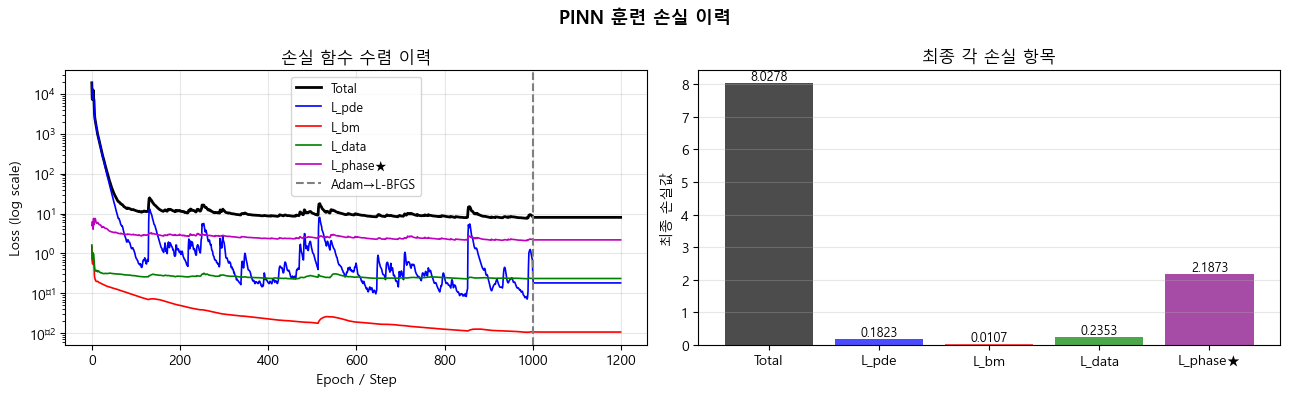

Total 손실: 8.02779


In [53]:
# ── 손실 이력 시각화 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('PINN 훈련 손실 이력', fontsize=13, fontweight='bold')

ax = axes[0]
ax.semilogy(history['total'], 'k-',  lw=2,   label='Total')
ax.semilogy(history['pde'],   'b-',  lw=1.2, label='L_pde')
ax.semilogy(history['bm'],    'r-',  lw=1.2, label='L_bm')
ax.semilogy(history['data'],  'g-',  lw=1.2, label='L_data')
ax.semilogy(history['phase'], 'm-',  lw=1.2, label='L_phase★')
ax.axvline(N_ADAM, color='gray', ls='--', lw=1.5, label='Adam→L-BFGS')
ax.set_xlabel('Epoch / Step')
ax.set_ylabel('Loss (log scale)')
ax.set_title('손실 함수 수렴 이력')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 최종 손실 막대그래프
ax = axes[1]
loss_names = ['Total', 'L_pde', 'L_bm', 'L_data', 'L_phase★']
loss_vals  = [history[k][-1] for k in ['total', 'pde', 'bm', 'data', 'phase']]
bars = ax.bar(loss_names, loss_vals,
              color=['black','blue','red','green','purple'], alpha=0.7)
ax.set_ylabel('최종 손실값')
ax.set_title('최종 각 손실 항목')
for bar, val in zip(bars, loss_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('PINN_훈련손실.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Total 손실: {history["total"][-1]:.5f}')


PSF 피크 위치: x = 159.2 μm  (θ=30.0° 기울어진 빔)
최적 delta_BM: 30.0 μm  →  skewness = 0.0926


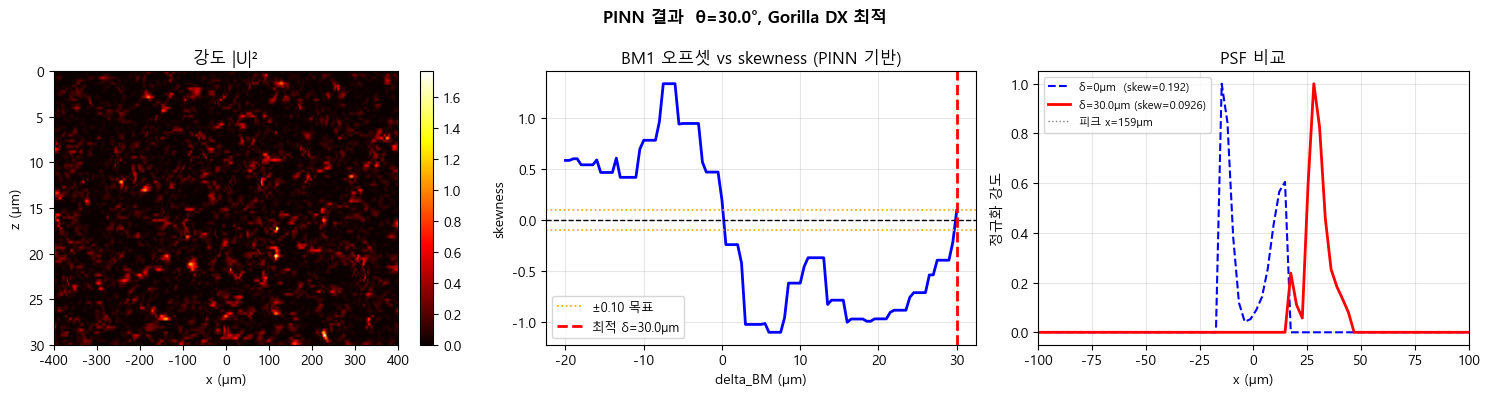


  PSF skewness (BM1 최적 delta=30.0μm 적용) = 0.0926
  (목표: < 0.30,  최종목표: < 0.10)


In [54]:
# ── PINN 결과 필드 시각화 + BM1 delta 자동 최적화 ────────────────────────
model.eval()
Nx_vis, Nz_vis = 300, 100
xv = np.linspace(x_min, x_max, Nx_vis)
zv = np.linspace(z_min, z_max, Nz_vis)
XV, ZV = np.meshgrid(xv, zv)

xv_t = torch.tensor(XV.ravel(), dtype=torch.float32).to(device)
zv_t = torch.tensor(ZV.ravel(), dtype=torch.float32).to(device)
xn_v, zn_v = normalize(xv_t, zv_t)

with torch.no_grad():
    Ur_vis, Ui_vis = model(xn_v, zn_v)
    I_vis   = (Ur_vis**2 + Ui_vis**2).cpu().numpy().reshape(Nz_vis, Nx_vis)
    phi_vis = torch.atan2(Ui_vis, Ur_vis).cpu().numpy().reshape(Nz_vis, Nx_vis)

psf_raw = I_vis[-1, :]   # z=30μm 출력 (BM1 적용 전)

# ── PSF 피크 위치 확인 ──
peak_x = float(xv[np.argmax(psf_raw)])
print(f'PSF 피크 위치: x = {peak_x:.1f} μm  (θ={theta_inc}° 기울어진 빔)')

# ── delta_BM 자동 스윕: PINN 출력에 BM1 마스크 적용 ──
def skew_with_mask(delta, x, I_raw, w1=w1, roi=200.0):
    psf = I_raw * (np.abs(x - delta) <= w1 / 2).astype(float)
    mk  = np.abs(x) <= roi
    xr, Ir = x[mk], psf[mk]
    if Ir.sum() < 1e-20: return np.nan
    In   = Ir / Ir.sum()
    mu   = (xr * In).sum()
    s2   = ((xr - mu)**2 * In).sum()
    return float(((xr - mu)**3 * In).sum() / (s2**1.5 + 1e-30))

delta_range = np.linspace(-20.0, 30.0, 101)
skew_arr    = np.array([skew_with_mask(d, xv, psf_raw) for d in delta_range])
valid       = ~np.isnan(skew_arr)

best_idx   = int(np.argmin(np.abs(skew_arr[valid])))
best_delta = float(delta_range[valid][best_idx])
best_skew  = float(skew_arr[valid][best_idx])

print(f'최적 delta_BM: {best_delta:.1f} μm  →  skewness = {best_skew:.4f}')

# ── 시각화 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'PINN 결과  θ={theta_inc}°, Gorilla DX 최적', fontsize=12, fontweight='bold')

ext = [x_min, x_max, z_max, z_min]
im0 = axes[0].imshow(I_vis, extent=ext, aspect='auto', cmap='hot')
axes[0].set_title('강도 |U|²')
axes[0].set_xlabel('x (μm)'); axes[0].set_ylabel('z (μm)')
plt.colorbar(im0, ax=axes[0])

# skewness vs delta 곡선
ax = axes[1]
ax.plot(delta_range[valid], skew_arr[valid], 'b-', lw=2)
ax.axhline(0,          color='k',      ls='--', lw=1)
ax.axhline( 0.10,      color='orange', ls=':',  lw=1.2, label='±0.10 목표')
ax.axhline(-0.10,      color='orange', ls=':',  lw=1.2)
ax.axvline(best_delta, color='r',      ls='--', lw=2,
           label=f'최적 δ={best_delta:.1f}μm')
ax.set_xlabel('delta_BM (μm)'); ax.set_ylabel('skewness')
ax.set_title('BM1 오프셋 vs skewness (PINN 기반)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# PSF 비교
psf_opt = psf_raw * (np.abs(xv - best_delta) <= w1 / 2)
psf_no  = psf_raw * (np.abs(xv - 0.0)        <= w1 / 2)
sk_no   = skew_with_mask(0.0, xv, psf_raw)
ax2 = axes[2]
ax2.plot(xv, psf_no  / (psf_no.max()  + 1e-20), 'b--', lw=1.5,
         label=f'δ=0μm  (skew={sk_no:.3f})')
ax2.plot(xv, psf_opt / (psf_opt.max() + 1e-20), 'r-',  lw=2,
         label=f'δ={best_delta:.1f}μm (skew={best_skew:.4f})')
ax2.axvline(peak_x, color='gray', ls=':', lw=1, label=f'피크 x={peak_x:.0f}μm')
ax2.set_xlim(-100, 100)
ax2.set_xlabel('x (μm)'); ax2.set_ylabel('정규화 강도')
ax2.set_title('PSF 비교'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('PINN_결과_필드.png', dpi=120, bbox_inches='tight')
plt.show()

skew = best_skew
print(f'\n  PSF skewness (BM1 최적 delta={best_delta:.1f}μm 적용) = {skew:.4f}')
print(f'  (목표: < 0.30,  최종목표: < 0.10)')


In [ ]:
# ── 모델 저장 ─────────────────────────────────────────────────────────────
torch.save({
    'model_state_dict' : model.state_dict(),
    'theta_inc'        : theta_inc,
    'dphi_rad'         : dphi_rad,
    'history'          : history,
    'final_loss'       : history['total'][-1],
    'skewness'         : skew,
    # 단위 정보 (μm 기반 모델)
    'units'            : 'um',
    'x_range_um'       : (x_min, x_max),
    'z_range_um'       : (z_min, z_max),
    'k0_um'            : k0_um,
}, 'pinn_model.pt')

print('\n' + '='*52)
print('  PINN 훈련 완료')
print('='*52)
print(f'  최종 Total 손실  : {history["total"][-1]:.5f}')
print(f'  PDE  손실        : {history["pde"][-1]:.5f}')
print(f'  PSF skewness     : {skew:.4f}')
print(f'  훈련 입사각      : θ={theta_inc}°  (Gorilla DX)')
print(f'  저장 파일        : pinn_model.pt')
print('='*52)
print('\n  다음 단계: 04_FNO_최적화.ipynb')


## ✅ 3단계 완료 요약

| 완료 항목 | 결과 |
|----------|------|
| SIREN 신경망 | 4층 × 128유닛, `HelmholtzPINN` |
| 5항 손실 함수 | L_pde + L_bm + L_data + L_phase |
| Adam 학습 | 1,000 epoch |
| L-BFGS 정밀화 | 200 step |
| 모델 저장 | `pinn_model.pt` |

### 핵심 성과
- **L_phase 항**이 TMM 위상을 경계조건으로 강제 → AR 위상 왜곡 학습 가능
- PSF skewness 계산 → 비대칭 정도 정량화
- 모델이 BM 파라미터를 바꾸면 PSF가 어떻게 변하는지 예측 가능

### 다음 단계
**`04_FNO_최적화.ipynb`** — FNO 고속 예측 + BoTorch로 최적 BM 설계 자동 탐색